# Supervision Lib Playground

https://supervision.roboflow.com/latest/

In [1]:
# !pip install supervision

### Detect and Annotate

https://supervision.roboflow.com/latest/how_to/detect_and_annotate/

#### Enable Long Paths in Windows

Open PowerShell as Administrator:

```
New-ItemProperty `
  -Path "HKLM:\SYSTEM\CurrentControlSet\Control\FileSystem" `
  -Name "LongPathsEnabled" `
  -Value 1 `
  -PropertyType DWORD `
  -Force

```

In [10]:
# !pip install -U ultralytics

#### Libraries

In [54]:
import cv2
import supervision as sv
from ultralytics import YOLO
import matplotlib.pyplot as plt

#### Run Detection

First, you'll need to obtain predictions from your object detection or segmentation model.

To run inference, initialize your chosen model and pass the source image to its predict or infer method. Supervision supports Roboflow Inference, Ultralytics YOLO, and Hugging Face Transformers -- select the tab matching your framework. The result is a framework-specific object you will convert to a Detections instance in the next step.

In [55]:
model = YOLO("yolov8n.pt")
image = cv2.imread("../imgs/panorama1.png")
results = model(image)[0]

print(results)


0: 480x640 1 cup, 1 tv, 1 laptop, 1060.0ms
Speed: 35.0ms preprocess, 1060.0ms inference, 109.5ms postprocess per image at shape (1, 3, 480, 640)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwic

#### Load Predictions into Supervision

Now that we have predictions from a model, we can load them into Supervision.

In [56]:
detections = sv.Detections.from_ultralytics(results)

print(detections)

Detections(xyxy=array([[     257.44,       168.3,      821.56,      544.31],
       [    0.71881,      478.42,      119.66,      946.64],
       [     113.29,      650.79,      232.51,      765.34]], dtype=float32), mask=None, confidence=array([    0.89168,     0.66183,      0.4058], dtype=float32), class_id=array([62, 63, 41]), tracker_id=None, data={'class_name': array(['tv', 'laptop', 'cup'], dtype='<U6')}, metadata={})


In [57]:
for det in detections:
    print(det[5])

{'class_name': np.str_('tv')}
{'class_name': np.str_('laptop')}
{'class_name': np.str_('cup')}


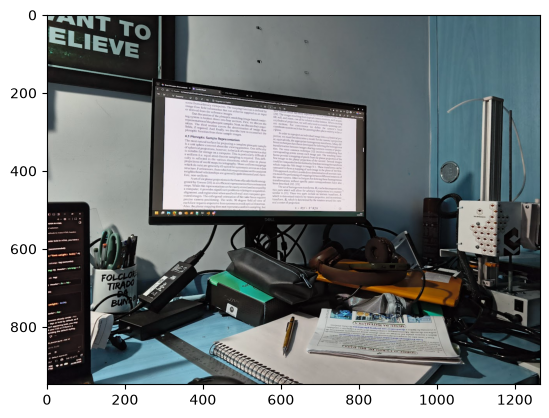

In [58]:
# The original image
plt.imshow(image)
plt.show()

#### Annotate Image with Detections

Finally, we can annotate the image with the predictions. Since we are working with an object detection model, we will use the sv.BoxAnnotator and sv.LabelAnnotator classes.


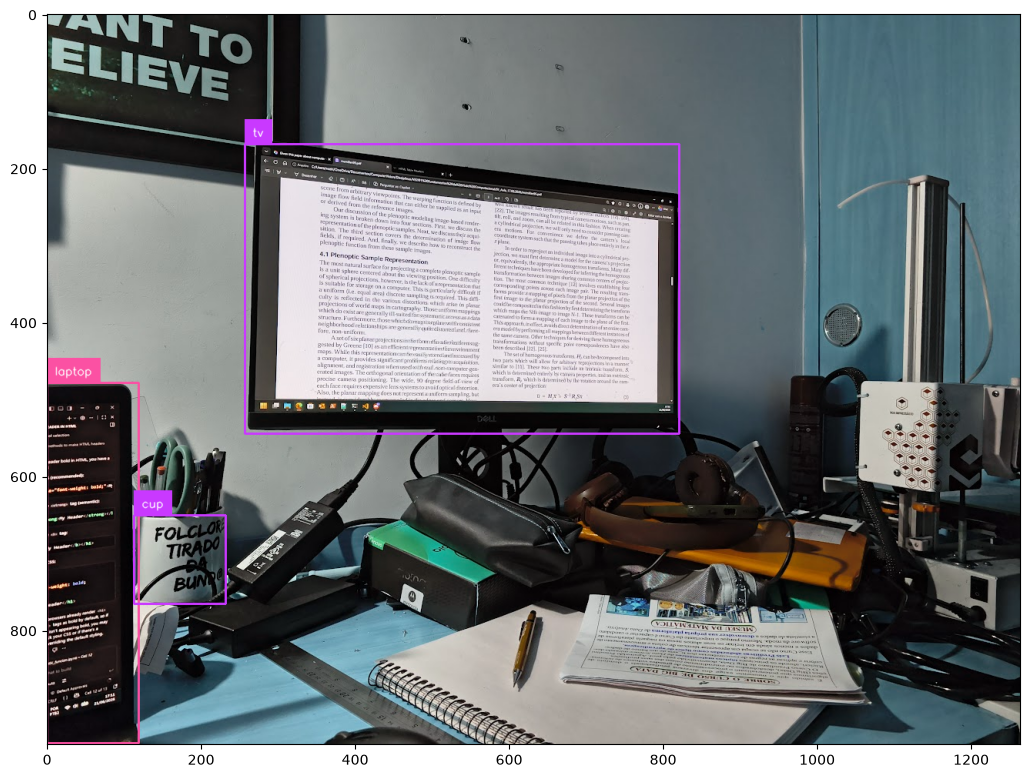

In [59]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = box_annotator.annotate(scene=image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

h, w = annotated_image.shape[:2]
plt.figure(figsize=(w/100, h/100))
plt.imshow(annotated_image)
plt.show()

#### Display Custom Labels

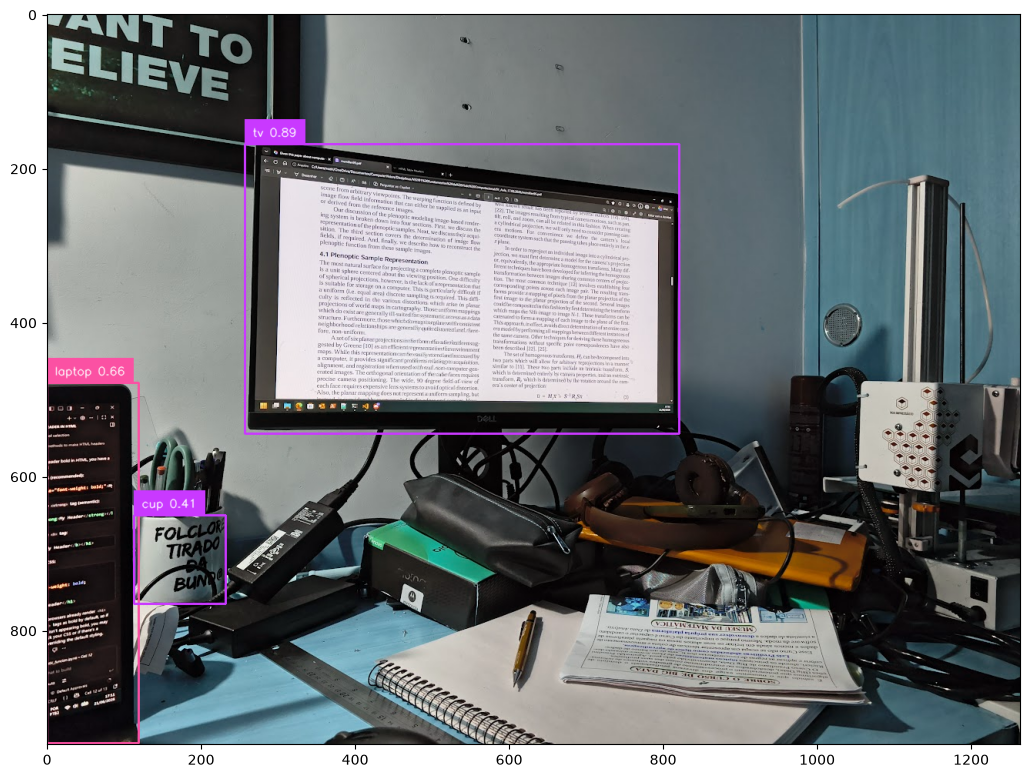

In [60]:
labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]

annotated_image = box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections, labels=labels)


h, w = annotated_image.shape[:2]
plt.figure(figsize=(w/100, h/100))
plt.imshow(annotated_image)
plt.show()

#### Annotate Image with Segmentations


0: 480x640 2 tvs, 1 laptop, 1 mouse, 1 keyboard, 244.2ms
Speed: 4.2ms preprocess, 244.2ms inference, 34.2ms postprocess per image at shape (1, 3, 480, 640)


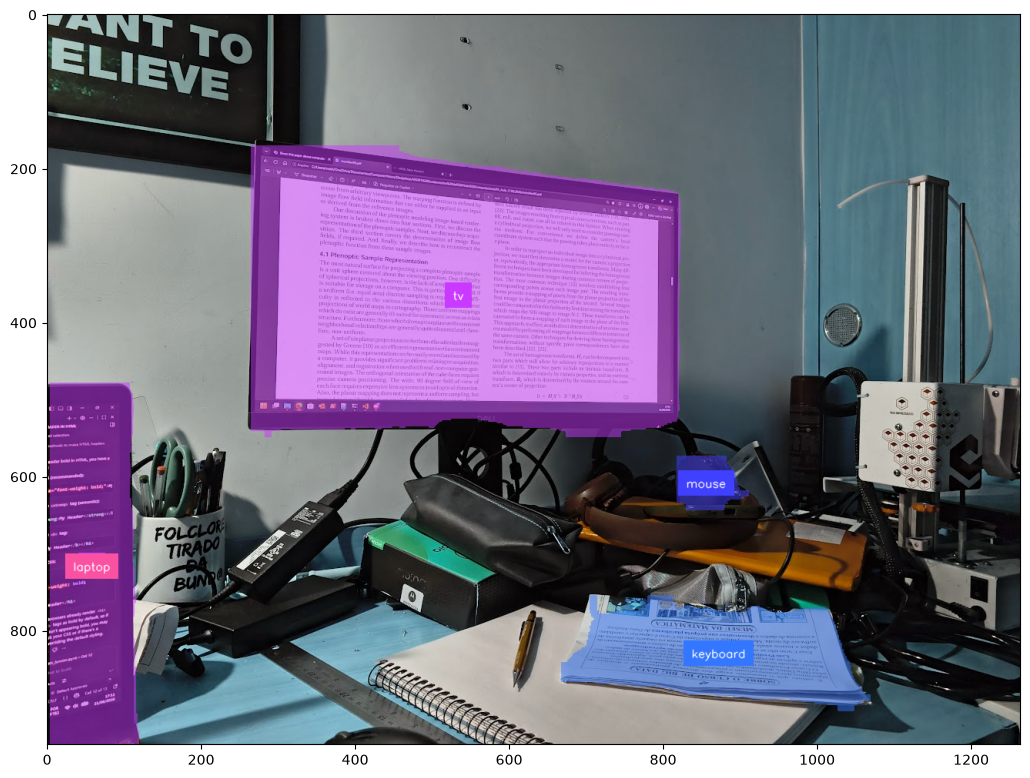

In [61]:
model = YOLO("yolov8n-seg.pt")
image = cv2.imread("../imgs/panorama1.png")
results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)

mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator(text_position=sv.Position.CENTER_OF_MASS)

annotated_image = mask_annotator.annotate(
    scene=image,
    detections=detections,
)
annotated_image = label_annotator.annotate(
    scene=annotated_image,
    detections=detections,
)

h, w = annotated_image.shape[:2]
plt.figure(figsize=(w/100, h/100))
plt.imshow(annotated_image)
plt.show()